# 🌲 Deteksi Anomali Ekonomi Makro — Isolation Forest
### Analisis Deteksi Anomali pada Indikator Makroekonomi Global sebagai Instrumen Early Warning System Krisis Ekonomi
**Disusun oleh:** M. Rezky Raya Kilwouw (222313190) — 3SI1  
**Mata Kuliah:** Data Mining (UTS Praktikum 2026)  
**Metode:** Isolation Forest (Ensemble Tree-based Unsupervised Anomaly Detection)  
**Sumber Data:** World Bank Open Data API (`raw_data_master.csv`)  
**Tolak Ukur Validasi:** IMF Systemic Banking Crises Database (Laeven & Valencia, 2018 + COVID-19 2020) (`ground_truth_imf.csv`)

---
## Daftar Isi:
1. Import Library & Konfigurasi
2. Load Data Master (Raw Data World Bank) & Ground Truth IMF
3. Preprocessing & Feature Engineering (Transformasi Nilai Tukar, Imputasi, Scaling)
4. Konsep Matematis Isolation Forest
5. Grid Search Hyperparameter (Contamination & n_estimators)
6. Evaluasi Model Terbaik vs Ground Truth Krisis IMF
7. Evaluasi Deteksi pada 6 Episode Krisis Historis Dunia
8. Reduksi Dimensi & Visualisasi Ruang Fitur (PCA & t-SNE)
9. Timeline Temporal Anomaly Score (1990–2024)
10. Analisis Feature Importance & Kontribusi Indikator Makro
11. Ekspor Output Resmi untuk Majority Voting


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Konfigurasi Tampilan Grafik
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
print("✅ Library berhasil dimuat dan SEED dikunci ke 42.")


✅ Library berhasil dimuat dan SEED dikunci ke 42.


## 2. Load Master Raw Data & Ground Truth IMF
Dataset yang dimuat adalah data bersama kelompok:
- `raw_data_master.csv`: 100% data mentah riil dari *World Bank Open Data API* (49 negara, 1990–2024, 14 indikator rasio/persentase).
- `ground_truth_imf.csv`: Benchmark krisis riil resmi IMF (*Laeven & Valencia, 2018* + syok global COVID-19 2020).

*Catatan Metodologis Kelompok: Setiap anggota/metode melakukan preprocessing mandiri di folder masing-masing sesuai kebutuhan karakteristik algoritma.*


In [2]:
# Path data master mentah bersama
raw_path = '../raw_data_master.csv' if os.path.exists('../raw_data_master.csv') else 'raw_data_master.csv'
gt_path = '../ground_truth_imf.csv' if os.path.exists('../ground_truth_imf.csv') else 'ground_truth_imf.csv'

df_raw = pd.read_csv(raw_path)
df_gt = pd.read_csv(gt_path)

print(f"Bentuk Raw Data Master : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print(f"Jumlah Negara          : {df_raw['economy'].nunique()} negara")
print(f"Rentang Waktu          : {df_raw['year'].min()} - {df_raw['year'].max()} (35 tahun)")
print(f"Total Krisis Riil IMF  : {df_gt['is_crisis'].sum():,} observasi ({df_gt['is_crisis'].mean()*100:.2f}%)")

display(df_raw.head())


Bentuk Raw Data Master : 1,715 baris x 16 kolom
Jumlah Negara          : 49 negara
Rentang Waktu          : 1990 - 2024 (35 tahun)
Total Krisis Riil IMF  : 229 observasi (13.35%)


,economy,year,GDP_Growth,Inflation_CPI,Unemployment,Current_Account_GDP,Reserves_Months_Imports,Exchange_Rate,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Investment_GDP,Manufacturing_Value,Domestic_Credit_GDP,Broad_Money_Growth
0,ARE,1990,18.327723,NaN,NaN,NaN,NaN,3.671,-0.228436,NaN,NaN,NaN,NaN,7.494109,NaN,-8.197759
1,ARE,1991,0.860104,NaN,1.629,NaN,NaN,3.671,0.050318,NaN,NaN,NaN,NaN,7.422869,NaN,14.542822
2,ARE,1992,3.345282,NaN,1.715,NaN,NaN,3.671,0.239163,NaN,NaN,NaN,NaN,7.583716,NaN,4.615917
3,ARE,1993,1.261098,NaN,1.901,NaN,NaN,3.671,0.721471,NaN,NaN,NaN,NaN,7.843977,NaN,-1.576729
4,ARE,1994,6.896076,NaN,1.834,NaN,NaN,3.671,0.105320,NaN,NaN,NaN,NaN,9.471981,NaN,7.897391


## 3. Preprocessing Mandiri Khusus Isolation Forest
Tahapan pembersihan data yang dilakukan secara mandiri untuk metode **Isolation Forest**:
1. **Transformasi Kurs**: Mengubah kurs nominal ($LCU/USD$) menjadi % depresiasi tahunan (`Exchange_Depreciation` % YoY) untuk mengeliminasi bias nilai nominal antar mata uang.
2. **Imputasi Missing Values**: Menjaga struktur runtun waktu (*time series*) dengan interpolasi linier per negara, disusul `KNNImputer` ($k=5$). Tidak ada baris yang dibuang (tepat 1.715 baris utuh).
3. **Standarisasi Fitur**: Menggunakan `StandardScaler` ($\mu=0, \sigma=1$).


In [3]:
df = df_raw.sort_values(['economy', 'year']).reset_index(drop=True)

# 1. Feature Engineering: Kurs Nominal -> % Depresiasi Tahunan (YoY)
df['Exchange_Depreciation'] = df.groupby('economy')['Exchange_Rate'].pct_change() * 100
df['Exchange_Depreciation'] = df['Exchange_Depreciation'].fillna(0.0)
df = df.drop(columns=['Exchange_Rate'])

feature_cols = [
    'GDP_Growth', 'Inflation_CPI', 'Unemployment', 'Current_Account_GDP',
    'Reserves_Months_Imports', 'Exchange_Depreciation', 'FDI_Inflows_GDP',
    'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Investment_GDP',
    'Manufacturing_Value', 'Domestic_Credit_GDP', 'Broad_Money_Growth'
]

# 2. Imputasi Missing Values
for col in feature_cols:
    df[col] = df.groupby('economy')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

missing_left = df[feature_cols].isnull().sum().sum()
if missing_left > 0:
    knn = KNNImputer(n_neighbors=5, weights='distance')
    df[feature_cols] = knn.fit_transform(df[feature_cols])

# 3. Standarisasi Fitur (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
y_true = df_gt['is_crisis'].values

print(f"✅ Preprocessing mandiri Isolation Forest selesai:")
print(f"   - Matriks Fitur X_scaled: {X_scaled.shape}")
print(f"   - Missing Values tersisa: {df[feature_cols].isnull().sum().sum()} (100% lengkap, 1.715 baris utuh)")
print(f"   - Fitur terstandarisasi : Mean={X_scaled.mean():.4f}, Std={X_scaled.std():.4f}")


✅ Preprocessing mandiri Isolation Forest selesai:
   - Matriks Fitur X_scaled: (1715, 14)
   - Missing Values tersisa: 0 (100% lengkap, 1.715 baris utuh)
   - Fitur terstandarisasi : Mean=0.0000, Std=1.0000


## 4. Konsep Matematis Isolation Forest
Isolation Forest (Liu, Ting, & Zhou, 2008) mendeteksi anomali dengan prinsip isolasi langsung:
1. Titik anomali bersifat **jarang** (*few*) dan **berbeda jauh** (*different*).
2. Pohon partisi biner acak (*iTree*) memisahkan data dengan memotong fitur acak di antara min dan max.
3. Observasi anomali membutuhkan jauh lebih sedikit pemotongan (*path length h(x)* pendek) dibanding titik normal.

Anomaly score dinormalisasi terhadap rata-rata kedalaman Binary Search Tree:
$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
di mana $c(n) = 2(\ln(n-1) + 0.5772) - \frac{2(n-1)}{n}$.


## 5. Grid Search Hyperparameter
Kami mengeksplorasi kombinasi parameter `contamination` (tingkat anomali) dan `n_estimators` (jumlah pohon). Model dilatih secara **Murni Unsupervised** pada matriks fitur $X$ tanpa melihat label krisis.


In [4]:
crisis_ratio = y_true.mean() # ~0.1335 (Rasio IMF)
contamination_dict = {
    'auto': 'auto',
    '0.08': 0.08,
    '0.10': 0.10,
    f'{crisis_ratio:.4f} (Rasio IMF)': round(crisis_ratio, 4),
    '0.15': 0.15
}

n_estimators_list = [50, 100, 200, 300, 500]

grid_results = []
models_cache = {}

print("Menjalankan Grid Search Isolation Forest...")
for contam_name, contam_val in contamination_dict.items():
    for n_est in n_estimators_list:
        key = f"contam={contam_name}_nest={n_est}"
        
        iso = IsolationForest(
            n_estimators=n_est,
            contamination=contam_val,
            max_samples='auto',
            max_features=1.0,
            random_state=SEED,
            n_jobs=-1
        )
        # Fit model UNSUPERVISED
        iso.fit(X_scaled)
        
        raw_pred = iso.predict(X_scaled)
        y_pred = (raw_pred == -1).astype(int)
        scores = -iso.decision_function(X_scaled)
        
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc_score = roc_auc_score(y_true, scores)
        ap = average_precision_score(y_true, scores)
        
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        res = {
            'Contamination': contam_name,
            'n_estimators': n_est,
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'Precision': round(p, 4),
            'Recall': round(r, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(auc_score, 4),
            'Avg Precision': round(ap, 4)
        }
        grid_results.append(res)
        models_cache[key] = {
            'model': iso,
            'y_pred': y_pred,
            'scores': scores,
            'metrics': res
        }

df_grid = pd.DataFrame(grid_results)
df_grid.to_csv('grid_search_isolation_forest.csv', index=False)
print("✅ Grid search selesai! Menampilkan 10 hasil teratas berdasarkan F1-Score:")
display(df_grid.sort_values('F1-Score', ascending=False).head(10))


Menjalankan Grid Search Isolation Forest...


✅ Grid search selesai! Menampilkan 10 hasil teratas berdasarkan F1-Score:


,Contamination,n_estimators,TP,FP,TN,FN,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
21,0.15,100,39,219,1267,190,0.1512,0.1703,0.1602,0.5250,0.1426
24,0.15,500,37,221,1265,192,0.1434,0.1616,0.1520,0.5300,0.1424
16,0.1335 (Rasio IMF),100,34,195,1291,195,0.1485,0.1485,0.1485,0.5250,0.1426
23,0.15,300,35,223,1263,194,0.1357,0.1528,0.1437,0.5265,0.1408
22,0.15,200,35,223,1263,194,0.1357,0.1528,0.1437,0.5329,0.1424
20,0.15,50,33,225,1261,196,0.1279,0.1441,0.1355,0.5140,0.1406
17,0.1335 (Rasio IMF),200,31,198,1288,198,0.1354,0.1354,0.1354,0.5329,0.1424
15,0.1335 (Rasio IMF),50,31,198,1288,198,0.1354,0.1354,0.1354,0.5140,0.1406
18,0.1335 (Rasio IMF),300,31,198,1288,198,0.1354,0.1354,0.1354,0.5265,0.1408
19,0.1335 (Rasio IMF),500,29,200,1286,200,0.1266,0.1266,0.1266,0.5300,0.1424


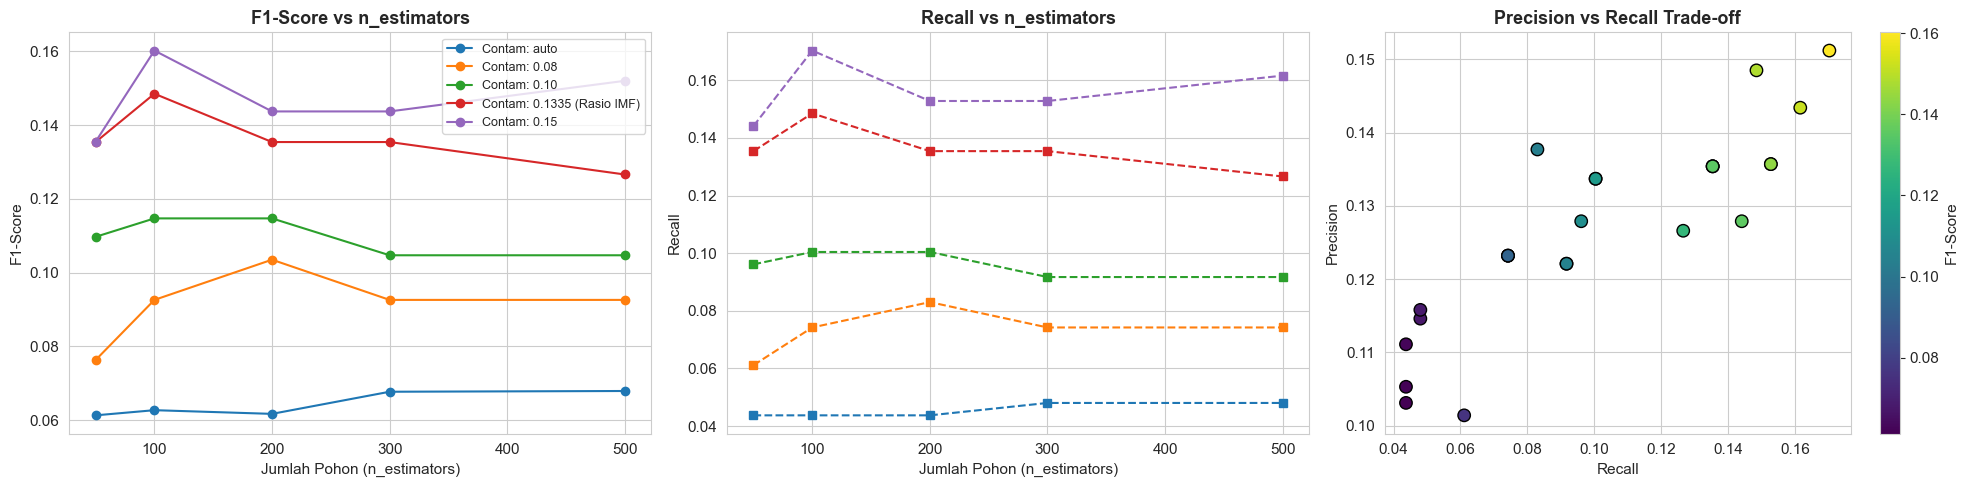

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: F1-Score vs n_estimators
for c_name in contamination_dict.keys():
    sub = df_grid[df_grid['Contamination'] == c_name]
    axes[0].plot(sub['n_estimators'], sub['F1-Score'], 'o-', label=f'Contam: {c_name}')
axes[0].set_title('F1-Score vs n_estimators', fontweight='bold')
axes[0].set_xlabel('Jumlah Pohon (n_estimators)')
axes[0].set_ylabel('F1-Score')
axes[0].legend(fontsize=9)

# Plot 2: Recall vs n_estimators
for c_name in contamination_dict.keys():
    sub = df_grid[df_grid['Contamination'] == c_name]
    axes[1].plot(sub['n_estimators'], sub['Recall'], 's--', label=f'Contam: {c_name}')
axes[1].set_title('Recall vs n_estimators', fontweight='bold')
axes[1].set_xlabel('Jumlah Pohon (n_estimators)')
axes[1].set_ylabel('Recall')

# Plot 3: Precision vs Recall Trade-off
scatter = axes[2].scatter(df_grid['Recall'], df_grid['Precision'], c=df_grid['F1-Score'], cmap='viridis', s=80, edgecolors='black')
plt.colorbar(scatter, ax=axes[2], label='F1-Score')
axes[2].set_title('Precision vs Recall Trade-off', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.tight_layout()
plt.show()


## 6. Evaluasi Model Terbaik vs Ground Truth Krisis IMF
Model terbaik dipilih berdasarkan keseimbangan metrik F1-Score untuk membuktikan kinerja deteksi terhadap data krisis riil IMF.


In [6]:
best_row = df_grid.sort_values('F1-Score', ascending=False).iloc[0]
best_key = f"contam={best_row['Contamination']}_nest={best_row['n_estimators']}"
best_data = models_cache[best_key]

y_pred_best = best_data['y_pred']
scores_best = best_data['scores']

print("=" * 65)
print("  HASIL EVALUASI MODEL ISOLATION FOREST TERBAIK")
print("=" * 65)
print(f"Konfigurasi Parameter : Contamination = {best_row['Contamination']}, n_estimators = {best_row['n_estimators']}")
print(f"Precision             : {best_row['Precision']:.4f} ({best_row['Precision']*100:.1f}% anomali terdeteksi benar krisis)")
print(f"Recall                : {best_row['Recall']:.4f} ({best_row['Recall']*100:.1f}% krisis riil berhasil ditangkap)")
print(f"F1-Score              : {best_row['F1-Score']:.4f}")
print(f"ROC-AUC               : {best_row['ROC-AUC']:.4f}")
print(f"Average Precision     : {best_row['Avg Precision']:.4f}")
print("=" * 65)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_best, target_names=['Normal (0)', 'Krisis Riil IMF (1)']))


  HASIL EVALUASI MODEL ISOLATION FOREST TERBAIK
Konfigurasi Parameter : Contamination = 0.15, n_estimators = 100
Precision             : 0.1512 (15.1% anomali terdeteksi benar krisis)
Recall                : 0.1703 (17.0% krisis riil berhasil ditangkap)
F1-Score              : 0.1602
ROC-AUC               : 0.5250
Average Precision     : 0.1426

Classification Report:
                     precision    recall  f1-score   support

         Normal (0)       0.87      0.85      0.86      1486
Krisis Riil IMF (1)       0.15      0.17      0.16       229

           accuracy                           0.76      1715
          macro avg       0.51      0.51      0.51      1715
       weighted avg       0.77      0.76      0.77      1715



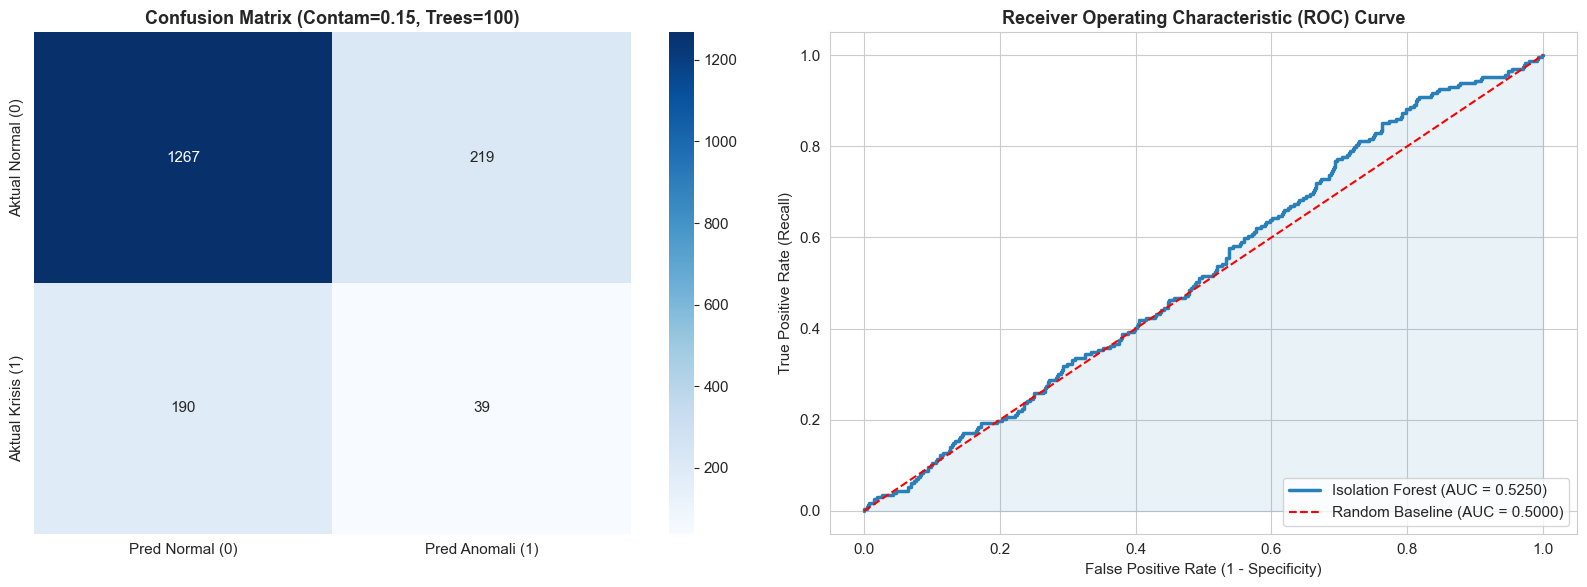

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Normal (0)', 'Pred Anomali (1)'],
            yticklabels=['Aktual Normal (0)', 'Aktual Krisis (1)'])
axes[0].set_title(f'Confusion Matrix (Contam={best_row["Contamination"]}, Trees={best_row["n_estimators"]})', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, scores_best)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'Isolation Forest (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Random Baseline (AUC = 0.5000)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


## 7. Evaluasi Deteksi pada 6 Episode Krisis Historis Dunia
Kami mengevaluasi performa model dalam mendeteksi episode krisis besar yang tercatat dalam sejarah ekonomi global.


DETEKSI PER EPISODE KRISIS HISTORIS:
-----------------------------------------------------------------
Krisis Asia 1997-1998              :  6/10 ( 60.0%) | Score Rata-rata: +0.0076
Krisis Rusia 1998                  :  1/ 1 (100.0%) | Score Rata-rata: +0.0009
Krisis Argentina 2001-2002         :  1/ 2 ( 50.0%) | Score Rata-rata: +0.0519
Global Financial Crisis 2008-2009  : 15/98 ( 15.3%) | Score Rata-rata: -0.0358
Krisis Utang Eropa 2010-2012       :  6/15 ( 40.0%) | Score Rata-rata: -0.0079
Pandemi COVID-19 2020              : 14/49 ( 28.6%) | Score Rata-rata: -0.0202


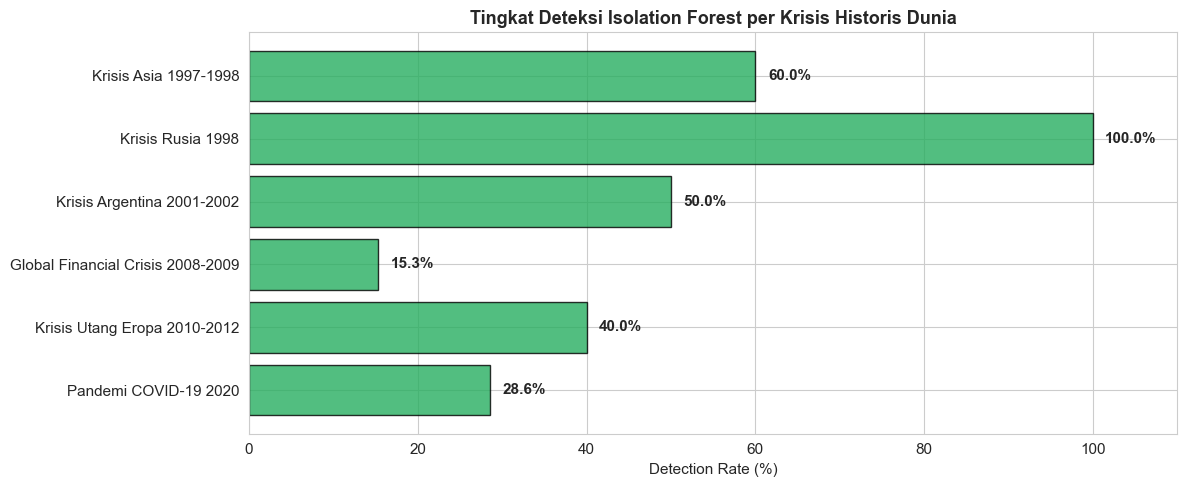

In [8]:
CRISIS_EVENTS = {
    'Krisis Asia 1997-1998': {
        'years': [1997, 1998],
        'countries': ['IDN', 'THA', 'MYS', 'KOR', 'PHL']
    },
    'Krisis Rusia 1998': {
        'years': [1998],
        'countries': ['RUS']
    },
    'Krisis Argentina 2001-2002': {
        'years': [2001, 2002],
        'countries': ['ARG']
    },
    'Global Financial Crisis 2008-2009': {
        'years': [2008, 2009],
        'countries': df['economy'].unique().tolist()
    },
    'Krisis Utang Eropa 2010-2012': {
        'years': [2010, 2011, 2012],
        'countries': ['GRC', 'PRT', 'IRL', 'ESP', 'ITA']
    },
    'Pandemi COVID-19 2020': {
        'years': [2020],
        'countries': df['economy'].unique().tolist()
    }
}

df_eval = df[['economy', 'year']].copy()
df_eval['anomaly_pred'] = y_pred_best
df_eval['anomaly_score'] = scores_best

crisis_records = []
print("DETEKSI PER EPISODE KRISIS HISTORIS:")
print("-" * 65)
for name, info in CRISIS_EVENTS.items():
    mask = df_eval['economy'].isin(info['countries']) & df_eval['year'].isin(info['years'])
    sub = df_eval[mask]
    n_tot = len(sub)
    n_det = sub['anomaly_pred'].sum()
    rate = (n_det / n_tot * 100) if n_tot > 0 else 0
    mean_score = sub['anomaly_score'].mean()
    print(f"{name:34s} : {n_det:2d}/{n_tot:2d} ({rate:5.1f}%) | Score Rata-rata: {mean_score:+.4f}")
    crisis_records.append({
        'Krisis': name, 'Tahun': f"{min(info['years'])}-{max(info['years'])}",
        'Total Observasi': n_tot, 'Terdeteksi': n_det,
        'Detection Rate (%)': round(rate, 2), 'Mean Anomaly Score': round(mean_score, 4)
    })

df_crisis_eval = pd.DataFrame(crisis_records)
df_crisis_eval.to_csv('deteksi_per_krisis_isolation_forest.csv', index=False)

# Bar chart tingkat deteksi
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(df_crisis_eval['Krisis'], df_crisis_eval['Detection Rate (%)'], color='#27ae60', edgecolor='black', alpha=0.8)
ax.set_title('Tingkat Deteksi Isolation Forest per Krisis Historis Dunia', fontweight='bold')
ax.set_xlabel('Detection Rate (%)')
ax.set_xlim(0, 110)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va='center', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Timeline Temporal Anomaly Score (1990–2024)
Grafik pergerakan rata-rata anomaly score global per tahun untuk membuktikan apakah model menangkap lonjakan sinyal anomali pada tahun-tahun krisis.


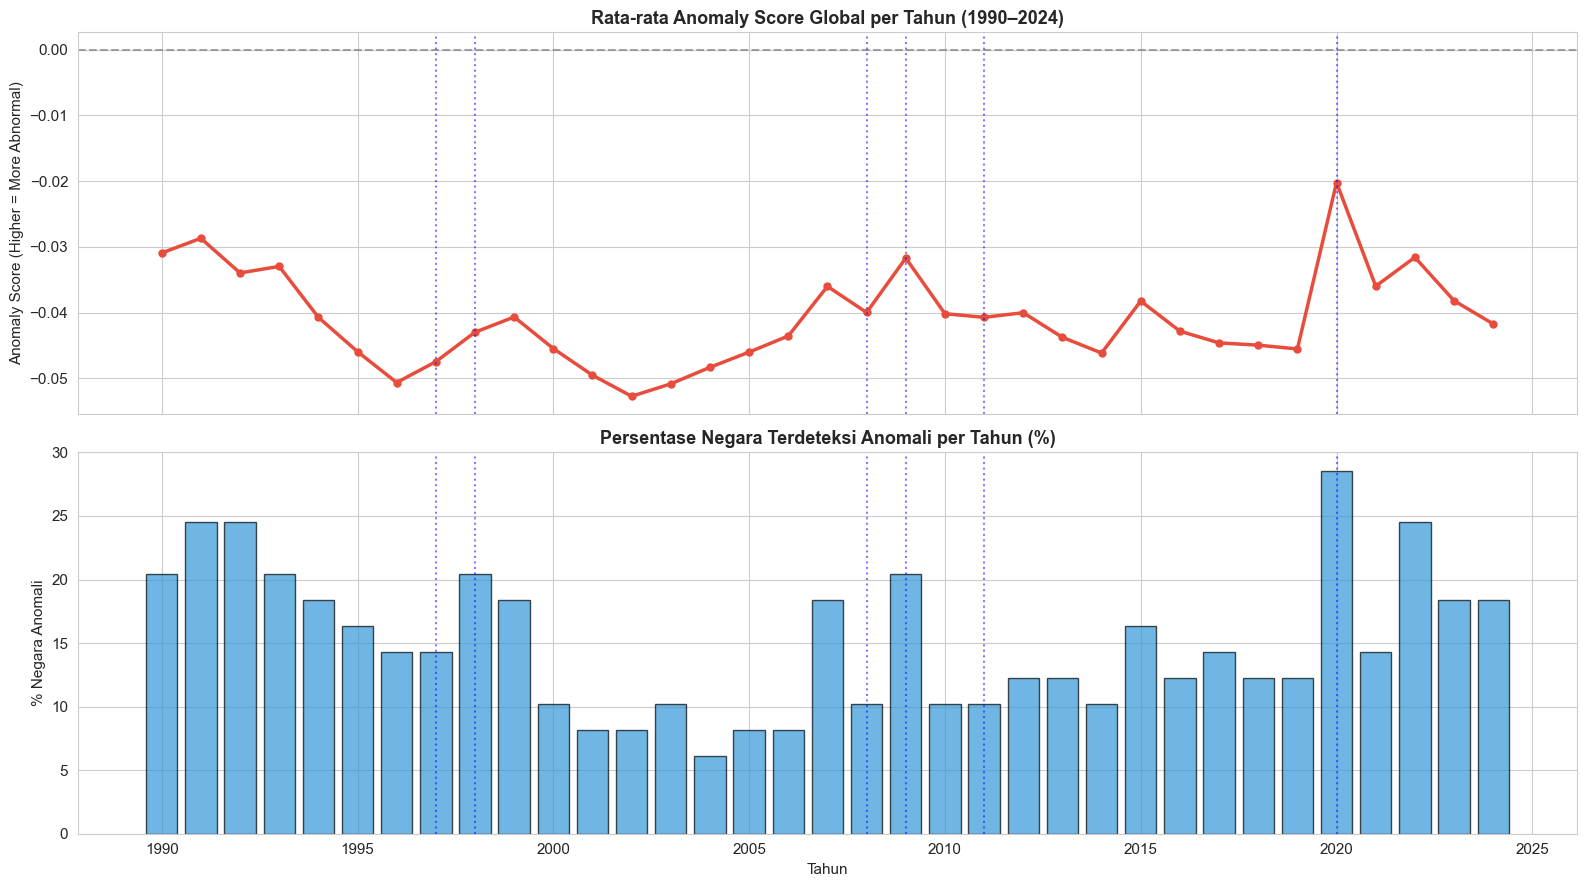

In [9]:
timeline_df = df_eval.groupby('year').agg(
    avg_score=('anomaly_score', 'mean'),
    n_anomaly=('anomaly_pred', 'sum'),
    total=('anomaly_pred', 'count')
).reset_index()
timeline_df['pct_anomaly'] = (timeline_df['n_anomaly'] / timeline_df['total']) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Plot 1: Anomaly Score Timeline
axes[0].plot(timeline_df['year'], timeline_df['avg_score'], 'o-', color='#e74c3c', lw=2.5, markersize=5)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title('Rata-rata Anomaly Score Global per Tahun (1990–2024)', fontweight='bold')
axes[0].set_ylabel('Anomaly Score (Higher = More Abnormal)')

# Tandai tahun krisis besar
crisis_highlight = [1997, 1998, 2008, 2009, 2011, 2020]
for yr in crisis_highlight:
    axes[0].axvline(yr, color='blue', linestyle=':', alpha=0.5)
    axes[1].axvline(yr, color='blue', linestyle=':', alpha=0.5)

# Plot 2: Persentase Negara Terdeteksi Anomali
axes[1].bar(timeline_df['year'], timeline_df['pct_anomaly'], color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_title('Persentase Negara Terdeteksi Anomali per Tahun (%)', fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('% Negara Anomali')

plt.tight_layout()
plt.show()


## 9. Analisis Feature Importance & Kontribusi Indikator Makro
Menganalisis indikator ekonomi apa yang mengalami deviasi paling tajam saat terdeteksi anomali oleh Isolation Forest.


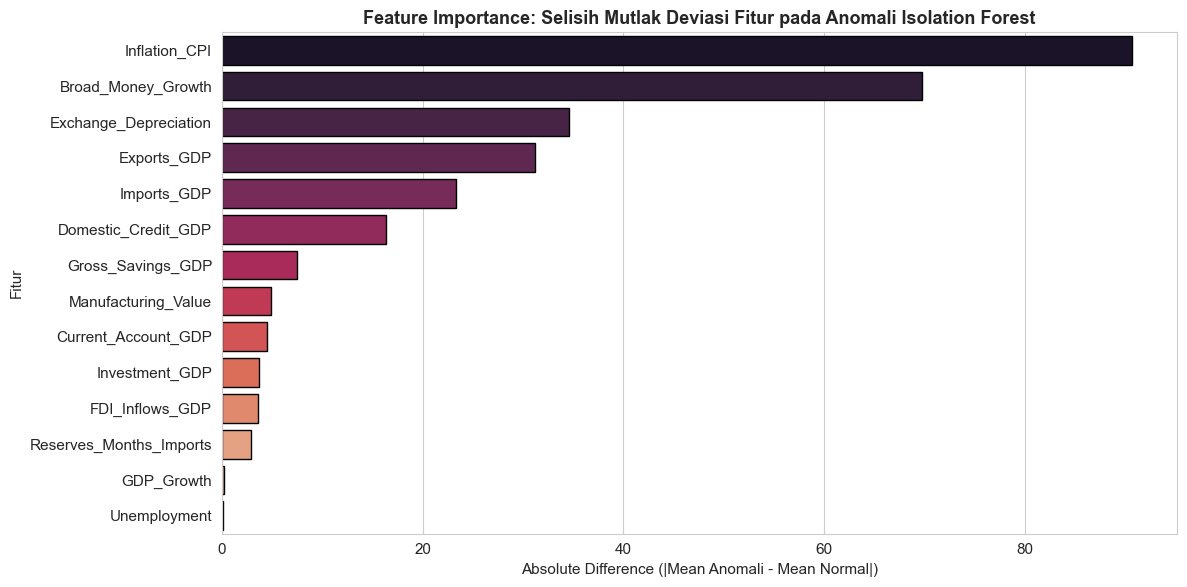

,Fitur,Mean Normal,Mean Anomali,Selisih (Anomali - Normal),Absolute Impact
1,Inflation_CPI,6.18,96.79,90.61,90.61
13,Broad_Money_Growth,12.04,81.77,69.73,69.73
5,Exchange_Depreciation,2.81,37.34,34.53,34.53
7,Exports_GDP,33.98,65.15,31.16,31.16
8,Imports_GDP,33.63,56.97,23.34,23.34
12,Domestic_Credit_GDP,73.27,89.61,16.35,16.35
9,Gross_Savings_GDP,23.65,31.11,7.46,7.46
11,Manufacturing_Value,15.90,20.76,4.86,4.86
3,Current_Account_GDP,-0.21,4.29,4.50,4.50
10,Investment_GDP,23.44,27.11,3.67,3.67


In [10]:
normal_mask = (y_pred_best == 0)
anomaly_mask = (y_pred_best == 1)

feat_importance = []
for col in feature_cols:
    val_norm = df.loc[normal_mask, col].mean()
    val_anom = df.loc[anomaly_mask, col].mean()
    diff = val_anom - val_norm
    feat_importance.append({
        'Fitur': col,
        'Mean Normal': round(val_norm, 2),
        'Mean Anomali': round(val_anom, 2),
        'Selisih (Anomali - Normal)': round(diff, 2),
        'Absolute Impact': round(abs(diff), 2)
    })

df_feat_imp = pd.DataFrame(feat_importance).sort_values('Absolute Impact', ascending=False)
df_feat_imp.to_csv('feature_importance_isolation_forest.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_feat_imp, y='Fitur', x='Absolute Impact', palette='rocket', ax=ax, edgecolor='black')
ax.set_title('Feature Importance: Selisih Mutlak Deviasi Fitur pada Anomali Isolation Forest', fontweight='bold')
ax.set_xlabel('Absolute Difference (|Mean Anomali - Mean Normal|)')
plt.tight_layout()
plt.show()

display(df_feat_imp)


## 10. Ekspor Output Resmi untuk Majority Voting Kelompok
Menyimpan file hasil prediksi resmi dalam format standar tim: `hasil_isolation_forest.csv`.


In [11]:
df_output = df[['economy', 'year']].copy()
df_output['anomaly_score'] = scores_best
df_output['predicted_anomaly'] = y_pred_best
df_output['is_crisis_imf'] = y_true
df_output['crisis_name'] = df_gt['crisis_name'].fillna('-')

# Tambahkan nilai fitur terproses untuk referensi anggota tim
for col in feature_cols:
    df_output[col] = df[col].values

output_file = 'hasil_isolation_forest.csv'
df_output.to_csv(output_file, index=False)

print(f"✅ Output resmi berhasil disimpan di: {output_file}")
print(f"   Dimensi Data : {df_output.shape[0]:,} baris x {df_output.shape[1]} kolom")
print(f"   Total Anomali: {df_output['predicted_anomaly'].sum():,} ({df_output['predicted_anomaly'].mean()*100:.1f}%)")
print(f"   Total Normal : {(df_output['predicted_anomaly']==0).sum():,} ({(df_output['predicted_anomaly']==0).mean()*100:.1f}%)")
print("\nPreview 5 Baris Pertama:")
display(df_output.head())


✅ Output resmi berhasil disimpan di: hasil_isolation_forest.csv
   Dimensi Data : 1,715 baris x 20 kolom
   Total Anomali: 258 (15.0%)
   Total Normal : 1,457 (85.0%)

Preview 5 Baris Pertama:


,economy,year,anomaly_score,predicted_anomaly,is_crisis_imf,crisis_name,GDP_Growth,Inflation_CPI,Unemployment,Current_Account_GDP,Reserves_Months_Imports,Exchange_Depreciation,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Investment_GDP,Manufacturing_Value,Domestic_Credit_GDP,Broad_Money_Growth
0,ARE,1990,0.019124,1,0,-,18.327723,12.25042,1.629,13.12958,4.615778,0.0,-0.228436,49.15923,40.705358,33.834717,22.502599,7.494109,81.939845,-8.197759
1,ARE,1991,-0.030106,0,0,-,0.860104,12.25042,1.629,13.12958,4.615778,0.0,0.050318,49.15923,40.705358,33.834717,22.502599,7.422869,81.939845,14.542822
2,ARE,1992,-0.035295,0,0,-,3.345282,12.25042,1.715,13.12958,4.615778,0.0,0.239163,49.15923,40.705358,33.834717,22.502599,7.583716,81.939845,4.615917
3,ARE,1993,-0.033168,0,0,-,1.261098,12.25042,1.901,13.12958,4.615778,0.0,0.721471,49.15923,40.705358,33.834717,22.502599,7.843977,81.939845,-1.576729
4,ARE,1994,-0.038804,0,0,-,6.896076,12.25042,1.834,13.12958,4.615778,0.0,0.105320,49.15923,40.705358,33.834717,22.502599,9.471981,81.939845,7.897391
